
# Moving Gas Stations away from Schools in Boston, MA

# Getting ready

## Installations needed

In [67]:
# !pip install osmnx mapclassify

## Data needed

### Official data preprocessing

We need the boston map. As we are going to analize schools and gas stations we must omit the water bodies. A good option is:


*   https://www.mass.gov/info-details/massgis-data-municipalities

You will select the shapefile for Boston from there. The file returned will be a zip, which I have saved on GitHub from where I read it:



In [68]:
import geopandas as gpd

filez="https://github.com/CienciaDeDatosEspacial/dataSets/raw/refs/heads/main/BOSTON/GISDATA.TOWNSSURVEY_POLYM.zip"
boston=gpd.read_file(filez)
boston.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   town        1 non-null      object  
 1   town_id     1 non-null      int32   
 2   type        1 non-null      object  
 3   county      1 non-null      object  
 4   fips_stco   1 non-null      int32   
 5   fourcolor   1 non-null      int32   
 6   pop1960     1 non-null      int32   
 7   pop1970     1 non-null      int32   
 8   pop1980     1 non-null      int32   
 9   pop1990     1 non-null      int32   
 10  pop2000     1 non-null      int32   
 11  pop2010     1 non-null      int32   
 12  pop2020     1 non-null      int32   
 13  popch10_20  1 non-null      int32   
 14  area_acres  1 non-null      float64 
 15  area_sqmi   1 non-null      float64 
 16  geometry    1 non-null      geometry
dtypes: float64(2), geometry(1), int32(11), object(3)
memory usage: 224.0+ bytes


As you see, it is just one geometry:

In [69]:
boston

,town,town_id,type,county,fips_stco,fourcolor,pop1960,pop1970,pop1980,pop1990,pop2000,pop2010,pop2020,popch10_20,area_acres,area_sqmi,geometry
0,BOSTON,35,C,SUFFOLK,25025,1,697197,641071,562994,574283,588957,617594,675647,58053,32104.34973,50.15997,"MULTIPOLYGON (((235056.153 904531.255, 235060...."


The map we have has come projected:

In [70]:
boston.crs

<Projected CRS: EPSG:26986>
Name: NAD83 / Massachusetts Mainland
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Massachusetts onshore - counties of Barnstable; Berkshire; Bristol; Essex; Franklin; Hampden; Hampshire; Middlesex; Norfolk; Plymouth; Suffolk; Worcester.
- bounds: (-73.5, 41.46, -69.86, 42.89)
Coordinate Operation:
- name: SPCS83 Massachusetts Mainland zone (meter)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### Crowdsourced data pre processing

Now we need the schools and gas stations. Let's become familiar with OpenStreet Maps [API for Python](https://osmnx.readthedocs.io/en/stable/), which for our case would be very useful.

You can get the gas stations from Boston like this:


In [71]:
# Get gas stations in Boston
import osmnx as ox

stations = ox.features_from_place("Boston, Massachusetts, USA",
                                tags={'amenity': 'fuel'})

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)


Notice we are getting several gas stations, already as a GDF:

In [72]:
stations.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 53 entries, ('node', np.int64(1547613299)) to ('way', np.int64(997511426))
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   geometry              53 non-null     geometry
 1   amenity               53 non-null     object  
 2   addr:city             21 non-null     object  
 3   addr:housenumber      26 non-null     object  
 4   addr:postcode         23 non-null     object  
 5   addr:state            20 non-null     object  
 6   addr:street           26 non-null     object  
 7   brand                 36 non-null     object  
 8   brand:wikidata        36 non-null     object  
 9   name                  44 non-null     object  
 10  opening_hours         7 non-null      object  
 11  compressed_air        11 non-null     object  
 12  source                4 non-null      object  
 13  ref                   7 non-null      object  
 1

OSM gave you stations unprojected:

In [73]:
stations.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Notice the multi-index:

In [74]:
stations

geometry  \
element  id                                                               
node     1547613299                          POINT (-71.11921 42.27983)   
         1915267811                          POINT (-71.12623 42.35823)   
         1975943661                          POINT (-71.05651 42.32059)   
         2086266695                          POINT (-71.15482 42.29539)   
         2108017693                          POINT (-71.15664 42.26192)   
         2108018346                          POINT (-71.16118 42.25828)   
         2108019392                          POINT (-71.15166 42.28766)   
         4119910813                          POINT (-71.11833 42.29594)   
         4456008435                          POINT (-71.03919 42.37176)   
         4456091896                          POINT (-71.02777 42.37965)   
         4456091915                          POINT (-71.00924 42.38557)   
         5012538664                          POINT (-71.04636 42.28384)   
         7049179057                          POINT (-71.13113 42.28346)   
         7711828654                          POINT (-71.09536 42.34499)   
         7779156553                          POINT (-71.03967 42.38287)   
         7801604967                          POINT (-71.06318 42.37186)   
         8911740730                          POINT (-71.12258 42.24965)   
         9155798164                          POINT (-71.11235 42.33173)   
         9301640141                          POINT (-71.12988 42.35254)   
         9307561244                             POINT (-71.08 42.38247)   
         9826872460                          POINT (-71.13487 42.35426)   
         11512786470                         POINT (-71.11478 42.27676)   
         12636225024                         POINT (-71.15399 42.34196)   
         12850165667                         POINT (-71.14183 42.34454)   
         13205043192                          POINT (-71.07321 42.2714)   
         13205071184                          POINT (-71.1061 42.27145)   
         13227205788                         POINT (-71.06912 42.27873)   
relation 13500843     POLYGON ((-71.02803 42.36628, -71.02801 42.366...   
way      29520631     POLYGON ((-71.02751 42.37897, -71.02755 42.379...   
         29613466     POLYGON ((-71.0565 42.3211, -71.05662 42.32109...   
         29622378     POLYGON ((-71.05527 42.33449, -71.05539 42.334...   
         29648812     POLYGON ((-71.07091 42.33124, -71.07092 42.331...   
         29650844     POLYGON ((-71.08125 42.33912, -71.08128 42.339...   
         29677198     POLYGON ((-71.12761 42.23623, -71.1277 42.2362...   
         29778889     POLYGON ((-71.14953 42.35589, -71.1497 42.3559...   
         29779289     POLYGON ((-71.16721 42.35018, -71.16746 42.350...   
         29804770     POLYGON ((-71.05959 42.31409, -71.05971 42.314...   
         29805421     POLYGON ((-71.07033 42.33183, -71.07046 42.331...   
         29806343     POLYGON ((-71.09524 42.3456, -71.09529 42.3456...   
         29829809     POLYGON ((-71.11445 42.31527, -71.11447 42.315...   
         29831768     POLYGON ((-71.04202 42.28609, -71.04208 42.286...   
         29833313     POLYGON ((-71.04847 42.29561, -71.04855 42.295...   
         29887927     POLYGON ((-71.11912 42.27979, -71.11931 42.279...   
         29934166     POLYGON ((-71.10606 42.30727, -71.10635 42.307...   
         29941823     POLYGON ((-71.10334 42.33343, -71.10368 42.333...   
         29946760     POLYGON ((-71.05551 42.34139, -71.05548 42.341...   
         212124454    POLYGON ((-71.06475 42.32535, -71.06441 42.325...   
         212129122    POLYGON ((-71.11089 42.32082, -71.11083 42.320...   
         350480325    POLYGON ((-71.13054 42.36304, -71.13037 42.363...   
         405514198    POLYGON ((-71.08174 42.34024, -71.08186 42.340...   
         644451331    POLYGON ((-71.04768 42.28384, -71.04806 42.283...   
         723203623    POLYGON ((-71.13169 42.237, -71.13175 42.23701...   
         9975

In the multi index you see **nodes**, **relations**, and **ways**:

In [75]:
stations.index

MultiIndex([(    'node',  1547613299),
            (    'node',  1915267811),
            (    'node',  1975943661),
            (    'node',  2086266695),
            (    'node',  2108017693),
            (    'node',  2108018346),
            (    'node',  2108019392),
            (    'node',  4119910813),
            (    'node',  4456008435),
            (    'node',  4456091896),
            (    'node',  4456091915),
            (    'node',  5012538664),
            (    'node',  7049179057),
            (    'node',  7711828654),
            (    'node',  7779156553),
            (    'node',  7801604967),
            (    'node',  8911740730),
            (    'node',  9155798164),
            (    'node',  9301640141),
            (    'node',  9307561244),
            (    'node',  9826872460),
            (    'node', 11512786470),
            (    'node', 12636225024),
            (    'node', 12850165667),
            (    'node', 13205043192),
            (    'node', 

Some formatting may be needed at this stage:

- This will put current indexes back into the data, and numbers will appear:

In [76]:
stations.reset_index(drop=False,inplace=True)
stations.head()

,element,id,geometry,amenity,addr:city,addr:housenumber,addr:postcode,addr:state,addr:street,brand,...,brand:website,building,fuel:diesel,fuel:gasoline,layer,opening_hours:signed,operator,building:levels,fuel:octane_95,type
0,node,1547613299,POINT (-71.11921 42.27983),fuel,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,1915267811,POINT (-71.12623 42.35823),fuel,Allston,219,02134,MA,Cambridge Street,Shell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,1975943661,POINT (-71.05651 42.32059),fuel,Dorchester,888,02125,MA,Dorchester Avenue,Gulf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,2086266695,POINT (-71.15482 42.29539),fuel,NaN,NaN,NaN,NaN,NaN,Shell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,2108017693,POINT (-71.15664 42.26192),fuel,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Keep some columns:

In [77]:
colsToKeep=['element','name','geometry']
fuelBoston=stations[colsToKeep].copy()

- Reproject the data:

In [78]:
Boston_crs = "EPSG:26986"

fuelBoston = fuelBoston.to_crs(Boston_crs)

- Review:

In [79]:
fuelBoston.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   element   53 non-null     object  
 1   name      44 non-null     object  
 2   geometry  53 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 1.4+ KB


- From above, columns **name** of the gas station has missing values. We should rename those missing values:

In [80]:
fuelBoston.fillna({'name':'Unknown'},inplace=True)

- We usually use the names as row index. But row index should not have duplicates. Since several 'names' are the same (_Unknown_), we have to create new names:

In [81]:
fuelBoston.index.astype(str)+"_"+fuelBoston.name

0                0_Unknown
1                  1_Shell
2     2_Columbia Road Gulf
3                  3_Shell
4                4_Unknown
5               5_Speedway
6               6_Speedway
7           7_Emporium Gas
8                  8_Shell
9                  9_Mobil
10              10_Unknown
11                 11_Gulf
12              12_Unknown
13               13_Sunoco
14                14_Mobil
15                15_Shell
16                   16_BP
17                17_Citgo
18             18_Speedway
19             19_Speedway
20               20_Irving
21          21_Stop & Shop
22     22_Cumberland Farms
23                23_Mobil
24               24_Sunoco
25               25_Sunoco
26               26_Sunoco
27       27_Shell - Nouria
28                   28_BP
29             29_Speedway
30             30_Speedway
31               31_Sunoco
32                 32_Gulf
33                33_Mobil
34                 34_Gulf
35    35_Oak Square Sunoco
36               36_US Gas
3

Then,

In [82]:
fuelBoston['newname']=fuelBoston.index.astype(str)+"_"+fuelBoston.name
fuelBoston.set_index('newname',inplace=True)
fuelBoston.drop(columns=['name'],inplace=True)
fuelBoston.head()

,element,geometry
newname,,
0_Unknown,node,POINT (231409.205 892220.97)
1_Shell,node,POINT (230791.53 900926.709)
2_Columbia Road Gulf,node,POINT (236556.832 896773.514)
3_Shell,node,POINT (228464.872 893936.856)
4_Unknown,node,POINT (228329.637 890218.87)


See that **nodes** are points, **ways** are lines or simple shapes built from points, and **relations** are conceptual containers that group any of the other elements to represent complex features.

Let me compare with the geometries available:


In [83]:
import pandas as pd

pd.crosstab(fuelBoston.element,fuelBoston.geometry.geom_type, margins=True)


col_0,Point,Polygon,All
element,,,
node,27,0,27
relation,0,1,1
way,0,25,25
All,27,26,53


This is the 'relation' we have:

In [84]:
#original data
stations[stations.element=='relation']

,element,id,geometry,amenity,addr:city,addr:housenumber,addr:postcode,addr:state,addr:street,brand,...,brand:website,building,fuel:diesel,fuel:gasoline,layer,opening_hours:signed,operator,building:levels,fuel:octane_95,type
27,relation,13500843,"POLYGON ((-71.02803 42.36628, -71.02801 42.366...",fuel,NaN,45,02128,NaN,Transportation Way,Shell,...,NaN,roof,NaN,NaN,NaN,NaN,NaN,NaN,NaN,multipolygon


<Axes: >

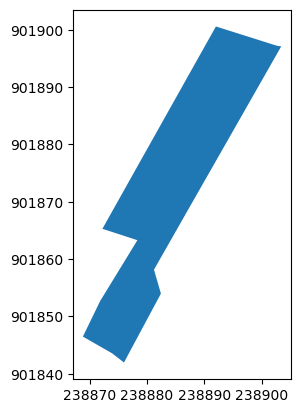

In [85]:
fuelBoston[fuelBoston.element=='relation'].plot()

Let me get the schools:

In [86]:
# Get schools in Boston
schools = ox.features_from_place("Boston, Massachusetts, USA",
                                tags={'amenity': 'school'})
schools.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 273 entries, ('node', np.int64(257493925)) to ('way', np.int64(1532859919))
Data columns (total 99 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   geometry                 273 non-null    geometry
 1   addr:city                185 non-null    object  
 2   addr:housenumber         198 non-null    object  
 3   addr:postcode            189 non-null    object  
 4   addr:state               166 non-null    object  
 5   addr:street              199 non-null    object  
 6   amenity                  273 non-null    object  
 7   attribution              116 non-null    object  
 8   education                231 non-null    object  
 9   gnis:feature_id          126 non-null    object  
 10  jurisdiction             1 non-null      object  
 11  name                     264 non-null    object  
 12  old_name                 12 non-null     object  
 13  sou

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predi

Let's reformat this as we did before:

In [87]:
schools.reset_index(inplace=True)
schoolBoston=schools[['element','name','geometry']].copy()
schoolBoston.fillna({'name':'Unknown'},inplace=True)
schoolBoston['newname']=schoolBoston.index.astype(str)+"_"+schoolBoston.name
schoolBoston.set_index('newname',inplace=True)
schoolBoston.drop(columns=['name'],inplace=True)
schoolBoston = schoolBoston.to_crs(Boston_crs)
schoolBoston.head()


,element,geometry
newname,,
0_Boston Police Academy,node,POINT (231587.542 888708.322)
1_Urban Science Academy,node,POINT (226876.32 892442.908)
2_Boston Middle School Academy,node,POINT (234181.887 894623.399)
3_Ralph Waldo Emerson School,node,POINT (235209.779 897088.628)
4_John Paul II Polish School,node,POINT (236451.673 897587.454)


See element vs geo:

In [88]:
pd.crosstab(schoolBoston.element,schoolBoston.geometry.geom_type, margins=True)

col_0,MultiPolygon,Point,Polygon,All
element,,,,
node,0,110,0,110
relation,2,0,5,7
way,0,0,156,156
All,2,110,161,273


In [89]:
#original data
schools[(schools.element=='relation') & (schools.geometry.geom_type=='MultiPolygon')]

,element,id,geometry,addr:city,addr:housenumber,addr:postcode,addr:state,addr:street,amenity,attribution,...,max_age,min_age,official_name,name:etymology:wikidata,mascot,note,isced:level,wikipedia:en,preschool,office
113,relation,3844332,"MULTIPOLYGON (((-71.16686 42.27773, -71.16687 ...",West Roxbury,235,02132,NaN,Baker Street,school,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,relation,20508982,"MULTIPOLYGON (((-71.10854 42.30559, -71.10876 ...",Jamaica Plain,144,02130,MA,McBride Street,school,Office of Geographic and Environmental Informa...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

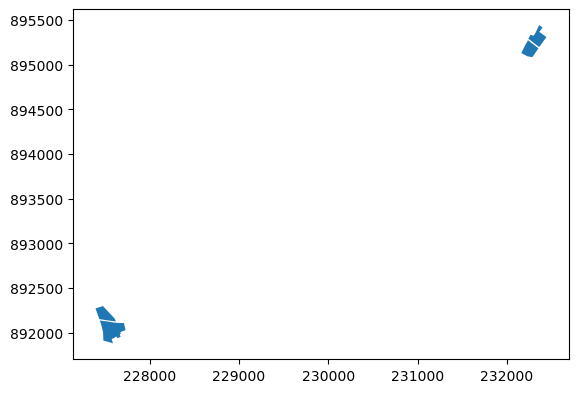

In [90]:
schoolBoston[(schoolBoston.element=='relation') & (schoolBoston.geometry.geom_type=='MultiPolygon')].plot()

In [91]:
base=boston.explore(tiles='cartodbpositron',color='lightblue')
schoolBoston.explore(m=base,color='k')
fuelBoston.explore(m=base,color='red')

# Explore proximity:


Let's compute a couple of distance matrices.

- The distance among fuel stations

In [92]:
D_Matrix_fuel_fuel=fuelBoston.geometry.apply\
(lambda station: fuelBoston.geometry.distance(station))

D_Matrix_fuel_fuel

newname,0_Unknown,1_Shell,2_Columbia Road Gulf,3_Shell,4_Unknown,5_Speedway,6_Speedway,7_Emporium Gas,8_Shell,9_Mobil,...,43_Stan Hatoff's,44_Shell,45_Southie Gas,46_Stop & Shop Gas,47_Unknown,48_Nouria,49_Shell,50_Speedway,51_Roger's Services,52_Unknown
newname,,,,,,,,,,,,,,,,,,,,,
0_Unknown,0.000000,8727.624383,6871.952298,3407.837938,3673.165372,4209.712154,2813.964173,1790.404515,12155.739962,13406.427002,...,3234.495836,6095.242575,8620.620270,6760.384459,4602.264652,9268.657342,7386.485428,5883.133123,4859.744681,3884.455796
1_Shell,8727.624383,0.000000,7105.472646,7366.911850,10987.208647,11470.088910,8114.564055,6950.074505,7326.070600,8452.326268,...,5867.405363,3305.372464,6111.383061,6245.483625,4335.437151,616.085382,4161.170067,10476.799257,13464.010418,7763.762976
2_Columbia Road Gulf,6871.952298,7105.472646,0.000000,8574.756321,10519.035543,11064.397417,8655.942529,5785.564850,5859.694999,6974.418159,...,4331.598353,4113.489962,2305.082433,842.480604,4470.888788,7684.987331,3013.288615,4137.188866,11158.588417,9232.804703
3_Shell,3407.837938,7366.911850,8574.756321,0.000000,3720.444951,4155.568688,898.002993,3009.853106,12757.986963,14043.510851,...,4214.095164,5977.659946,9649.672607,8137.399622,4593.183084,7756.624042,7816.711177,8895.324825,6749.625704,658.507965
4_Unknown,3673.165372,10987.208647,10519.035543,3720.444951,0.000000,551.674425,2887.510892,4925.464710,15575.071746,16847.787266,...,6537.960311,9075.109742,12142.358940,10345.864017,7552.207045,11415.891646,10668.029754,9280.123532,3438.443402,3554.262419
5_Speedway,4209.712154,11470.088910,11064.397417,4155.568688,551.674425,0.000000,3356.249306,5476.509621,16125.184185,17398.324182,...,7088.725747,9611.237999,12694.008878,10896.053762,8091.038429,11887.740132,11215.288798,9752.331375,3381.108526,3926.944945
6_Speedway,2813.964173,8114.564055,8655.942529,898.002993,2887.510892,3356.249306,0.000000,2898.499218,13160.329148,14445.328375,...,4333.507414,6451.824616,9921.847613,8299.281817,4987.120000,8532.628063,8205.612961,8552.623751,5851.664047,1113.725238
7_Emporium Gas,1790.404515,6950.074505,5785.564850,3009.853106,4925.464710,5476.509621,2898.499218,0.000000,10652.080578,11923.094113,...,1613.378546,4343.655419,7231.798174,5494.062792,2829.639930,7499.948706,5771.354957,5946.473052,6630.252668,3648.146781
8_Shell,12155.739962,7326.070600,5859.694999,12757.986963,15575.071746,16125.184185,13160.329148,10652.080578,0.000000,1285.853822,...,9022.483011,6774.589101,3607.101370,5539.856088,8167.336183,7572.694395,4943.083430,9781.300877,16792.563919,13357.391330


From here, we can compute the minimal distance among those gas stations:

In [93]:
D_Matrix_fuel_fuel.replace(0,None,inplace=True) # avoid the zero
D_Matrix_fuel_fuel.min(axis=1).sort_values().head(10)

newname
29_Speedway              55.729518
2_Columbia Road Gulf     55.729518
31_Sunoco                66.650839
37_Unknown               66.650839
13_Sunoco                67.991699
38_Shell                 67.991699
9_Mobil                  69.527035
28_BP                    69.527035
11_Gulf                 108.648957
50_Speedway             108.648957
dtype: object

- The distance among gas stations and schools:

In [94]:
D_Matrix_fuel_school=fuelBoston.geometry.apply\
(lambda station: schoolBoston.geometry.distance(station))

D_Matrix_fuel_school

newname,0_Boston Police Academy,1_Urban Science Academy,2_Boston Middle School Academy,3_Ralph Waldo Emerson School,4_John Paul II Polish School,5_Academy Of the Pacific Rim Charter Public School,6_Smith Leadership Academy Charter Public School,7_The Learning Project Elementary School,8_Lyndon,9_Eliot Elementary,...,263_Sarah Greenwood School,264_Joyce Kilmer School,265_The Patrick Lyndon Pilot School,266_Frank W Thompson Middle School,267_Josiah Quincy Elementary School,268_Josiah Quincy Upper School,269_Italian Home for Children School,270_Baldwin Early Learning Pilot Academy,271_Unknown,272_Unknown
newname,,,,,,,,,,,,,,,,,,,,,
0_Unknown,3517.172373,4538.314533,3668.709777,6175.633927,7363.805994,3955.280914,5531.851825,8892.716105,3078.082221,11011.884118,...,3696.466905,3648.966085,3204.880248,3107.703357,8744.745535,8763.768694,2519.578877,7087.581859,8607.902374,3026.664823
1_Shell,12244.290100,9343.647624,7157.251605,5852.503222,6571.745828,12526.745937,8427.175998,4082.135425,7593.700123,6065.516344,...,7751.590351,10007.607833,8728.125278,9298.057232,5126.352377,5244.669476,6028.525154,2121.034960,2980.094857,7568.625546
2_Columbia Road Gulf,9473.181799,10605.020433,3203.648108,1383.419611,820.705094,10411.205910,2152.076759,4033.072522,8484.410901,5060.790603,...,3206.964180,10249.275203,9342.070973,4752.045981,3060.289866,3001.370974,6018.628205,7289.493423,9257.867471,8460.748620
3_Shell,6090.044288,2180.682657,5758.089941,7444.959838,8781.563134,5845.185924,7955.167693,9097.280039,368.378525,11471.081097,...,6117.847196,2645.098933,1366.297789,6237.546105,9379.137516,9436.950650,2315.987018,5264.869832,6174.392988,345.806303
4_Unknown,3591.058820,2656.779444,7324.527882,9722.650156,10966.471948,2720.954364,9187.416199,12106.466319,3432.549911,14365.388885,...,7367.528360,1164.308095,2283.368252,6557.039305,12135.911449,12169.615827,5097.389773,8948.992059,9876.412225,3383.456675
5_Speedway,3795.183476,2843.577257,7867.642325,10273.832679,11515.960465,2784.007788,9711.387849,12650.106349,3888.425893,14913.672863,...,7899.815126,1466.066277,2688.826633,7049.037738,12685.902982,12719.957550,5635.160194,9409.662571,10273.262204,3841.026634
6_Speedway,5222.069546,1958.824895,5667.363486,7620.966318,8942.451556,4947.709018,7815.937994,9556.758148,558.089978,11897.024151,...,5949.102681,1939.012041,729.211464,5821.401338,9743.653141,9792.926447,2552.817236,6061.526440,7055.310554,506.490232
7_Emporium Gas,5303.105183,4857.317730,2776.611052,4840.864788,6129.893860,5712.458287,4954.791044,7244.811933,2824.351629,9454.617256,...,3108.466172,4488.656268,3563.095519,3435.568293,7214.053460,7245.923486,932.157757,5398.289935,7043.232742,2790.025372
8_Shell,15157.800501,14938.190513,8701.081274,6035.637704,5102.936681,15977.085163,7990.823376,3720.893692,12809.569431,1326.803963,...,8908.669623,15018.745338,13889.526123,10568.544008,3324.605580,3348.450704,10446.347546,8940.827972,10303.231692,12789.132993


# Decision 1: Find the stations that should go away



Now, we could compute the minimal distance from a gas station to a school, and sort the stations by that value:

In [95]:
D_Matrix_fuel_school.min(axis=1).sort_values().head(10)

newname
28_BP                    16.344538
36_US Gas                16.817808
43_Stan Hatoff's         23.196254
8_Shell                  47.383312
9_Mobil                  91.365677
2_Columbia Road Gulf     96.766745
29_Speedway              98.044988
41_Citgo                100.187359
49_Shell                171.630269
42_Unknown              176.522893
dtype: float64

By the previous exploration, we may decide that no station should at 100 or less from a school:

In [96]:
mindDist=100

# Decision 2: Secure perimeter of every school

Let's create the safe area around the school. This requires **buffer**:

In [97]:
schoolBoston_buffered=schoolBoston.buffer(mindDist)
schoolBoston_buffered

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


newname
0_Boston Police Academy                     POLYGON ((231687.542 888708.322, 231687.061 88...
1_Urban Science Academy                     POLYGON ((226976.32 892442.908, 226975.839 892...
2_Boston Middle School Academy              POLYGON ((234281.887 894623.399, 234281.406 89...
3_Ralph Waldo Emerson School                POLYGON ((235309.779 897088.628, 235309.297 89...
4_John Paul II Polish School                POLYGON ((236551.673 897587.454, 236551.191 89...
                                                                  ...                        
268_Josiah Quincy Upper School              POLYGON ((235930.783 899885.411, 235974.218 89...
269_Italian Home for Children School        POLYGON ((230557.526 894717.821, 230549.825 89...
270_Baldwin Early Learning Pilot Academy    POLYGON ((229681.711 899007.822, 229674.544 89...
271_Unknown                                 POLYGON ((228014.632 900144.611, 228011.939 90...
272_Unknown                                 POLYGON 

In [98]:
#remember we have
type(schoolBoston_buffered)

geopandas.geoseries.GeoSeries

Turning GS into GDF:

In [99]:
secured_schoolBoston=gpd.GeoDataFrame(geometry=schoolBoston_buffered)
secured_schoolBoston

,geometry
newname,
0_Boston Police Academy,"POLYGON ((231687.542 888708.322, 231687.061 88..."
1_Urban Science Academy,"POLYGON ((226976.32 892442.908, 226975.839 892..."
2_Boston Middle School Academy,"POLYGON ((234281.887 894623.399, 234281.406 89..."
3_Ralph Waldo Emerson School,"POLYGON ((235309.779 897088.628, 235309.297 89..."
4_John Paul II Polish School,"POLYGON ((236551.673 897587.454, 236551.191 89..."
...,...
268_Josiah Quincy Upper School,"POLYGON ((235930.783 899885.411, 235974.218 89..."
269_Italian Home for Children School,"POLYGON ((230557.526 894717.821, 230549.825 89..."
270_Baldwin Early Learning Pilot Academy,"POLYGON ((229681.711 899007.822, 229674.544 89..."


Buffers created polygons:

In [100]:
secured_schoolBoston.geometry.geom_type.value_counts()

Polygon    273
Name: count, dtype: int64

# Decision 3: Standardized Gas stations geometries

Not all gas stations are points:

In [101]:
fuelBoston.geometry.geom_type.value_counts()

Point      27
Polygon    26
Name: count, dtype: int64

The point is a simple representation. Then let's make a buffer of 10 meters for every station to make sure the station is selected even if we just had one of its points.

In [102]:
fuelBoston_allPoly=fuelBoston.copy()
fuelBoston_allPoly['geometry'] = [
    station.buffer(10) if station.geom_type == 'Point' else station
    for station in fuelBoston.geometry
]

In [103]:
# rechecking
fuelBoston_allPoly.geometry.geom_type.value_counts()

Polygon    53
Name: count, dtype: int64

# Decision 4: Overlay or SJoin to determine gas stations in trouble

This is great moment to test our understanding of these ops:

- do you want to move the points from the gas stations that are close to the schools?

In [104]:
fuelBoston_allPoly.overlay(secured_schoolBoston,how='intersection',keep_geom_type=False)

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


,element,geometry
0,node,"POLYGON ((236558.783 896763.706, 236557.812 89..."
1,node,"POLYGON ((237964.427 902463.107, 237964.283 90..."
2,node,"POLYGON ((237964.427 902463.107, 237964.283 90..."
3,node,"POLYGON ((238900.171 903345.039, 238900.027 90..."
4,way,"POLYGON ((238908.242 903276.883, 238915.107 90..."
5,way,"POLYGON ((236547.608 896829.127, 236547.577 89..."
6,way,"POLYGON ((236296.682 896059.083, 236302.183 89..."
7,way,"POLYGON ((232455.662 895290.441, 232464.542 89..."


- do you want to move the gas stations that are close to the schools?

In [105]:
fuelBoston_allPoly.sjoin(secured_schoolBoston,how='inner',predicate='intersects')

,element,geometry,newname_right
newname_left,,,
2_Columbia Road Gulf,node,"POLYGON ((236566.832 896773.514, 236566.784 89...",137_Pope John Paul II Catholic Academy
8_Shell,node,"POLYGON ((237964.475 902464.087, 237964.427 90...",238_Dante Alighieri Montessori School
8_Shell,node,"POLYGON ((237964.475 902464.087, 237964.427 90...",239_East Boston Central Catholic
9_Mobil,node,"POLYGON ((238900.219 903346.019, 238900.171 90...",212_Excel Academy Charter School
28_BP,way,"POLYGON ((238911.72 903270.471, 238908.242 903...",212_Excel Academy Charter School
29_Speedway,way,"POLYGON ((236557.367 896829.256, 236547.608 89...",137_Pope John Paul II Catholic Academy
36_US Gas,way,"POLYGON ((236306.663 896049.993, 236296.682 89...",175_Edward Everett Elementary School
43_Stan Hatoff's,way,"POLYGON ((232479.958 895273.092, 232455.662 89...",116_The English High


The obvious choice is using **sjoin** + **intersects** (why not within?).

In [106]:
gas_relocate=fuelBoston_allPoly.sjoin(secured_schoolBoston,how='inner',predicate='intersects')

It is possible the index may have duplicates:

In [107]:
is_duplicate = gas_relocate.index.duplicated(keep=False)

gas_relocate[is_duplicate]

,element,geometry,newname_right
newname_left,,,
8_Shell,node,"POLYGON ((237964.475 902464.087, 237964.427 90...",238_Dante Alighieri Montessori School
8_Shell,node,"POLYGON ((237964.475 902464.087, 237964.427 90...",239_East Boston Central Catholic


Remember our names are on the row index, then:

In [108]:
# put the index as a column: reset_index(drop=False)
# drop duplicates in that column:drop_duplicates(subset='newname_left')
# column bask to index : set_index('newname_left')

gas_relocate.reset_index(drop=False).\
drop_duplicates(subset='newname_left').\
set_index('newname_left')

,element,geometry,newname_right
newname_left,,,
2_Columbia Road Gulf,node,"POLYGON ((236566.832 896773.514, 236566.784 89...",137_Pope John Paul II Catholic Academy
8_Shell,node,"POLYGON ((237964.475 902464.087, 237964.427 90...",238_Dante Alighieri Montessori School
9_Mobil,node,"POLYGON ((238900.219 903346.019, 238900.171 90...",212_Excel Academy Charter School
28_BP,way,"POLYGON ((238911.72 903270.471, 238908.242 903...",212_Excel Academy Charter School
29_Speedway,way,"POLYGON ((236557.367 896829.256, 236547.608 89...",137_Pope John Paul II Catholic Academy
36_US Gas,way,"POLYGON ((236306.663 896049.993, 236296.682 89...",175_Edward Everett Elementary School
43_Stan Hatoff's,way,"POLYGON ((232479.958 895273.092, 232455.662 89...",116_The English High


In [109]:
#making the actual change
gas_relocate= gas_relocate.reset_index(drop=False).drop_duplicates(subset='newname_left').\
              set_index('newname_left')

Let's see both schools and those stations to relocate:

In [110]:
base=secured_schoolBoston.sjoin(gas_relocate,how='inner',predicate='intersects').explore(color='yellow', tiles='cartodbpositron')
gas_relocate.explore(m=base,color='red')

# Decision 5: Find suitable places for the stations in trouble


We can not put the gas stations anywhere. They need to be situated on driveable routes, not inside a house or building.


- Find suitable locations along routes

Let's get the streets from Boston with the help of OSM:

In [111]:
# Define the place
place = "Boston, Massachusetts, USA"

# Download the street network graph for Boston
G = ox.graph_from_place(place, network_type="drive")

# Convert the graph edges (streets) to a GeoDataFrame
streets = ox.graph_to_gdfs(G, nodes=False, edges=True)

streets.shape

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)


(26186, 16)

You see we got a huge set of routes:

In [112]:
streets.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 26186 entries, (np.int64(30730954), np.int64(61441677), np.int64(0)) to (np.int64(14075935208), np.int64(61345001), np.int64(0))
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   osmid     26186 non-null  object  
 1   highway   26186 non-null  object  
 2   lanes     24427 non-null  object  
 3   maxspeed  24230 non-null  object  
 4   name      25467 non-null  object  
 5   oneway    26186 non-null  bool    
 6   reversed  26186 non-null  object  
 7   length    26186 non-null  float64 
 8   geometry  26186 non-null  geometry
 9   width     23417 non-null  object  
 10  ref       924 non-null    object  
 11  bridge    385 non-null    object  
 12  access    250 non-null    object  
 13  junction  106 non-null    object  
 14  tunnel    132 non-null    object  
 15  service   1 non-null      object  
dtypes: bool(1), float64(1), geometry(1), object(13)
memory 

Let's pay attention to the 'highway' column:

In [113]:
streets.highway.value_counts().index

Index([                    'residential',                       'secondary',
                               'primary',                        'tertiary',
                          'unclassified',                           'trunk',
                         'motorway_link',                    'primary_link',
                              'motorway',                          'busway',
                        'secondary_link',                      'trunk_link',
                         'living_street',                   'tertiary_link',
         ['residential', 'unclassified'], ['living_street', 'unclassified'],
        ['residential', 'living_street'],           ['road', 'residential'],
              ['residential', 'primary'],     ['primary_link', 'secondary'],
               ['tertiary', 'secondary'],          ['primary', 'secondary'],
                         'emergency_bay',    ['secondary', 'motorway_link'],
               ['trunk_link', 'primary']],
      dtype='object', name='highw

In [114]:
GAS_STATION_ROAD_TYPES = [
    'motorway',      # High-speed limited access roads
    'primary',       # Major national roads
    'trunk',         # Important regional roads
    'motorway_link', # Motorway entrance/exit ramps
    'primary_link',  # Primary road connectors
    'trunk_link',     # Trunk road connectors
    ['motorway', 'trunk'],
    ['primary', 'motorway_link'],
    ['primary', 'primary_link']
]

suitable_roads = streets[streets.highway.isin(GAS_STATION_ROAD_TYPES)]

suitable_roads.shape

(3984, 16)

Let's reproject:

In [115]:
suitable_roads = suitable_roads.to_crs(boston.crs)

The possible locations should be:
- Far enough from schools. They should be far from the GDF **secured_schoolBoston** (already buffered with a secure radius) .
- Far from other Gast stations. From **fuelBoston_allPoly** we could add a secured distance. This GDF was was buffered, but just to include the building, so we need to re buffer.

Then, we need to create a buffer around the stations:

In [116]:
competitionDistance=100 # a safe value from above 'D_Matrix_fuel_fuel'
fuelBoston_allPoly_buffered=fuelBoston_allPoly.buffer(competitionDistance)

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


Do we have a GDF?

In [117]:
type(fuelBoston_allPoly_buffered)

geopandas.geoseries.GeoSeries

In [118]:
secured_fuelBoston_allPoly=gpd.GeoDataFrame(geometry=fuelBoston_allPoly_buffered)


Let's combine the secured areas:



In [119]:
secured_areas_dissolved=secured_fuelBoston_allPoly.overlay(secured_schoolBoston,how='union',keep_geom_type=False).dissolve()
secured_areas=gpd.GeoDataFrame(geometry=secured_areas_dissolved.geometry)

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


- Filter the roads. We can NOT choose a location that intersects with the secured areas:

Choose: **overlay** vs **sjoin** vs **clip**?

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


<Axes: >

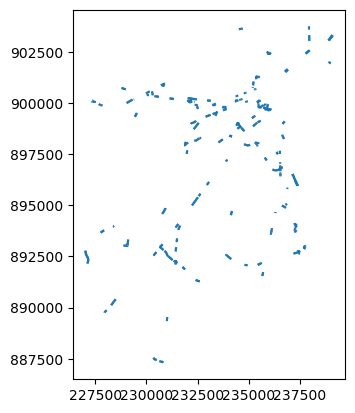

In [120]:
suitable_roads.clip(secured_areas,keep_geom_type=False).plot()

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)


<Axes: >

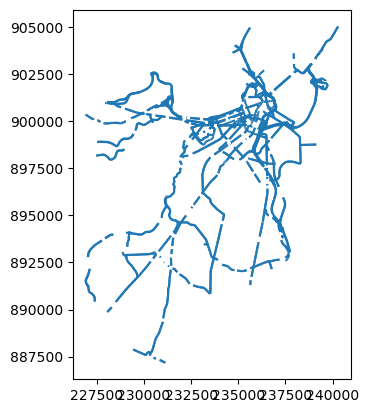

In [121]:
suitable_roads.overlay(secured_areas,keep_geom_type=False, how='difference').plot()

<Axes: >

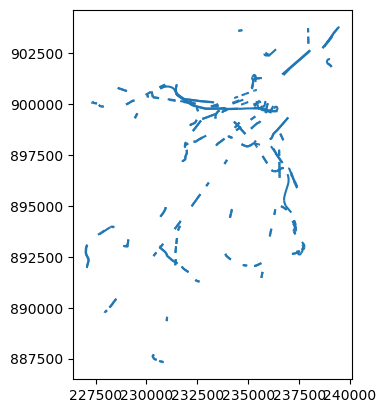

In [122]:
suitable_roads.sjoin(secured_areas, predicate='intersects').plot()

Why **clip** is a poor choice?
- Keeps only the parts that overlap with the mask. We want the opposite - to remove the overlapping parts (this would give you only roads inside school zones (the exact opposite!))

Why **sjoin** is a poor choice?
- You do get the precise locations that should not be included, you get the whole row element (more area). Since sjoin does not have a **not-intersects** predicate, this will also be wrong:

```
bad_geoms = suitable_roads.clip(secured_areas)
good_segments = suitable_roads.overlay(bad_geoms, how='difference')
```

Then:

In [123]:
good_routes_forGas_dissolved=suitable_roads.overlay(secured_areas,keep_geom_type=False, how='difference').dissolve()
good_routes_forGas=gpd.GeoDataFrame(geometry=good_routes_forGas_dissolved.geometry)
good_routes_forGas

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


,geometry
0,"MULTILINESTRING ((236538.63 896605.726, 236537..."


<Axes: >

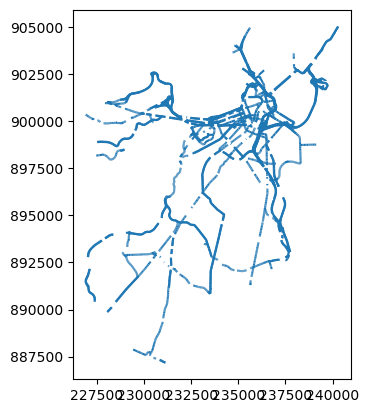

In [124]:
good_routes_forGas.plot()

We may choose a location from those places:

In [125]:
# newCOMPETITORS=safe_fuelCompetitors_gdf.copy()
potential_Locations=good_routes_forGas.copy()
newPOLYGONS=[]
pointsComputed=1
attempts=1
while pointsComputed<=len(gas_relocate):
  candidatePoint=potential_Locations.sample_points(1)
  candidateStation=gpd.GeoDataFrame(geometry=candidatePoint.buffer(100))
  if candidateStation.overlay(secured_areas,how='intersection',keep_geom_type=False).empty:
    newPOLYGONS.append(candidateStation)
    pointsComputed+=1
    potential_Locations=potential_Locations.overlay(candidateStation, how='difference', keep_geom_type=False)
  if attempts>len(gas_relocate)*10:
    break
  attempts+=1

# some info
attempts,len(newPOLYGONS)



/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/s

(9, 7)

In [126]:
newPOLYGONS

[                                            geometry
 0  POLYGON ((235595.814 899634.092, 235595.332 89...,
                                             geometry
 0  POLYGON ((229806.099 899874.079, 229805.618 89...,
                                             geometry
 0  POLYGON ((233856.286 898903.879, 233855.804 89...,
                                             geometry
 0  POLYGON ((239180.996 901013.211, 239180.515 90...,
                                             geometry
 0  POLYGON ((233081.231 899814.434, 233080.75 899...,
                                             geometry
 0  POLYGON ((235684.686 902701.11, 235684.204 902...,
                                             geometry
 0  POLYGON ((236407.786 899811.013, 236407.304 89...]

In [127]:
pd.concat(newPOLYGONS)

,geometry
0,"POLYGON ((235595.814 899634.092, 235595.332 89..."
0,"POLYGON ((229806.099 899874.079, 229805.618 89..."
0,"POLYGON ((233856.286 898903.879, 233855.804 89..."
0,"POLYGON ((239180.996 901013.211, 239180.515 90..."
0,"POLYGON ((233081.231 899814.434, 233080.75 899..."
0,"POLYGON ((235684.686 902701.11, 235684.204 902..."
0,"POLYGON ((236407.786 899811.013, 236407.304 89..."


In [128]:
GoodLocationsGas_buffered_gdf=pd.concat(newPOLYGONS)
GoodLocationsGas_gdf=gpd.GeoDataFrame(geometry=GoodLocationsGas_buffered_gdf.centroid)

<Axes: >

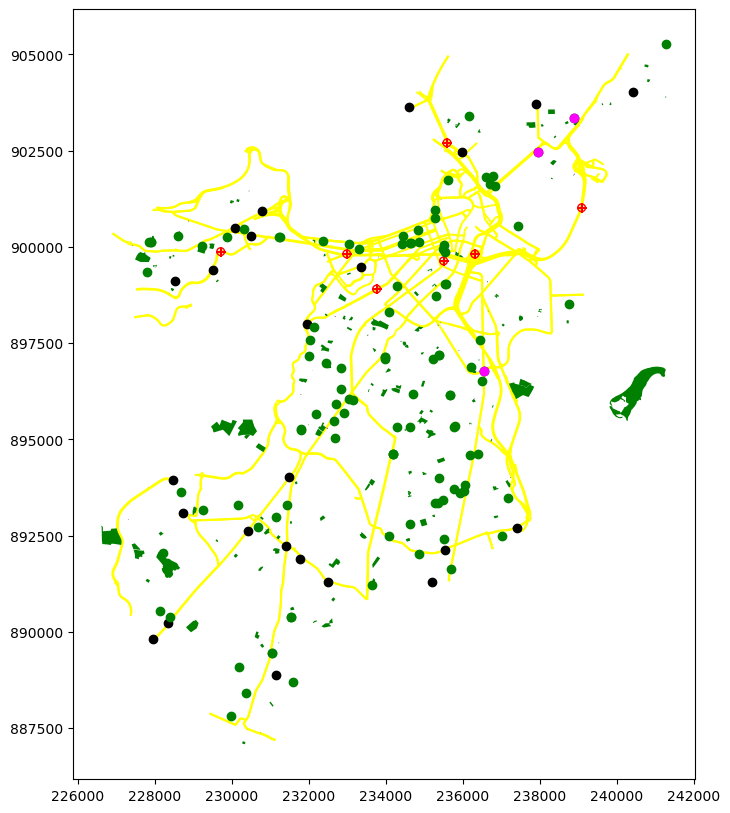

In [129]:
# original suitable roads
base = suitable_roads.plot(color='yellow', figsize=(10, 10),zorder=1)

# non-overlapping buffers
GoodLocationsGas_buffered_gdf.plot(ax=base, edgecolor='red', marker="+", facecolor='none',zorder=2)

# center points of the buffers
GoodLocationsGas_gdf.plot(ax=base, color='red', marker="+", markersize=50,zorder=3)

# all stations
fuelBoston.plot(ax=base,color='k',zorder=4)
schoolBoston.plot(ax=base,color='green',zorder=5)

# stations to relocate
fuelBoston.clip(gas_relocate).plot(ax=base,color='magenta',zorder=5)



# Decision 6 — Choose the new locations jointly

The previous section solved the relocation problem **sequentially**:

1. sample one feasible location;
2. reserve an area around it;
3. remove that area from the remaining opportunity set;
4. repeat until enough locations have been found.

That strategy is useful because it makes the spatial constraints very concrete. However, the result depends on the order in which locations are sampled. An early choice can remove a location that would have been part of a better overall solution.

We now keep everything learned above and add one final computational tool: **optimization**.

The question changes from:

> Can we find one acceptable location at a time?

to:

> **Can we choose all relocation locations at the same time, while respecting the spatial constraints?**

The spatial analysis has already constructed `good_routes_forGas`: road segments that remain available after removing the protected areas around schools and existing gas stations.

We will:

- generate a common pool of feasible candidate points on those roads;
- require one new location for every gas station that must relocate;
- prevent two selected new stations from being too close to each other;
- minimize the total relocation distance.

This is a simple **binary optimization** problem. Spatial analysis defines what is feasible; optimization chooses a compatible combination.


In [130]:

# If needed:
# !pip install -q pulp

import pulp
from sklearn.neighbors import NearestNeighbors



## 6.1 Create a common pool of feasible candidate locations

We do **not** create three candidates independently for each station. Instead, we sample a larger common pool from the feasible road network.

This is important because the final locations must work **together**.

The pool size can be increased for a larger or more demanding problem.


In [131]:

N_STATIONS = len(gas_relocate)

# Scalable workshop default:
# at least 200 candidates, or 40 candidates per station
N_CANDIDATES = max(200, 40 * N_STATIONS)

candidate_sample = good_routes_forGas.geometry.sample_points(
    size=N_CANDIDATES,
    rng=123
)

candidate_points = (
    gpd.GeoDataFrame(
        geometry=candidate_sample,
        crs=good_routes_forGas.crs
    )
    .explode(index_parts=False)
    .reset_index(drop=True)
)

candidate_points["Candidate ID"] = (
    "C" + candidate_points.index.astype(str)
)

print("Stations to relocate:", N_STATIONS)
print("Feasible candidate points:", len(candidate_points))


Stations to relocate: 7
Feasible candidate points: 280



## 6.2 Keep nearby alternatives for each affected station

A large city may contain thousands of feasible candidate points. There is no reason to create an optimization variable connecting every station to every point.

For scalability, each affected station considers only its **nearest \(K\) feasible candidates**.

This keeps the optimization problem compact while still giving every station several alternatives.


In [132]:

K_NEAREST = min(30, len(candidate_points))

stations_to_move = gas_relocate.copy()

# Use one representative point for each existing station geometry
stations_to_move["origin"] = (
    stations_to_move.geometry.representative_point()
)

candidate_xy = np.column_stack([
    candidate_points.geometry.x,
    candidate_points.geometry.y
])

station_xy = np.column_stack([
    stations_to_move["origin"].x,
    stations_to_move["origin"].y
])

nearest = NearestNeighbors(
    n_neighbors=K_NEAREST
)

nearest.fit(candidate_xy)

distances, indices = nearest.kneighbors(
    station_xy
)

assignment_rows = []

for station_pos, station_id in enumerate(stations_to_move.index):

    for rank, (distance, candidate_pos) in enumerate(
        zip(distances[station_pos], indices[station_pos]),
        start=1
    ):

        assignment_rows.append({
            "Station ID": station_id,
            "Candidate ID":
                candidate_points.iloc[candidate_pos]["Candidate ID"],
            "Distance (m)": float(distance),
            "Candidate rank": rank
        })

assignment_options = pd.DataFrame(
    assignment_rows
)

assignment_options.head()


NameError: name 'np' is not defined


## 6.3 Detect candidate locations that conflict with one another

The protected areas around **existing** stations were already removed when `good_routes_forGas` was created.

We must now add a different rule:

> Two **newly selected** gas stations must also remain at least a minimum distance apart.

Instead of comparing every candidate with every other candidate manually, we use a **spatial join**. This is more scalable because GeoPandas can use its spatial index to search only nearby geometries.


In [ ]:

MIN_NEW_STATION_DISTANCE = 100

candidate_buffers = candidate_points[
    ["Candidate ID", "geometry"]
].copy()

candidate_buffers["geometry"] = (
    candidate_buffers.geometry
    .buffer(MIN_NEW_STATION_DISTANCE)
)

conflict_table = (
    candidate_points[
        ["Candidate ID", "geometry"]
    ]
    .sjoin(
        candidate_buffers,
        how="inner",
        predicate="within",
        lsuffix="point",
        rsuffix="buffer"
    )
)

conflict_table = (
    conflict_table[
        conflict_table["Candidate ID_point"]
        != conflict_table["Candidate ID_buffer"]
    ]
    [["Candidate ID_point", "Candidate ID_buffer"]]
    .copy()
)

# Store each pair only once
conflict_table["pair"] = conflict_table.apply(
    lambda row: tuple(sorted((
        row["Candidate ID_point"],
        row["Candidate ID_buffer"]
    ))),
    axis=1
)

conflicts = (
    conflict_table["pair"]
    .drop_duplicates()
    .tolist()
)

print("Candidate conflict pairs:", len(conflicts))



## 6.4 Formulate the optimization problem

We create two kinds of binary decisions:

- \(x_{ic}=1\) when station \(i\) is assigned to candidate \(c\);
- \(y_c=1\) when candidate \(c\) is selected.

The model follows four simple rules:

1. every affected station receives exactly one new location;
2. a candidate can be assigned to at most one station;
3. two candidates that are too close cannot both be selected;
4. among all feasible combinations, minimize total relocation distance.

This formulation can be extended later with additional costs or restrictions without changing the basic structure.


In [ ]:

model = pulp.LpProblem(
    "Gas_Station_Relocation",
    pulp.LpMinimize
)

# Only create assignment variables for the nearby alternatives
option_keys = list(
    assignment_options[
        ["Station ID", "Candidate ID"]
    ].itertuples(
        index=False,
        name=None
    )
)

x = pulp.LpVariable.dicts(
    "assign",
    option_keys,
    cat="Binary"
)

candidate_ids = candidate_points[
    "Candidate ID"
].tolist()

y = pulp.LpVariable.dicts(
    "select",
    candidate_ids,
    cat="Binary"
)



### Objective: minimize total relocation distance


In [ ]:

distance_lookup = {
    (row["Station ID"], row["Candidate ID"]):
        row["Distance (m)"]

    for _, row in assignment_options.iterrows()
}

model += pulp.lpSum(
    distance_lookup[key] * x[key]
    for key in option_keys
)



### Constraint 1: exactly one location per affected station


In [ ]:

for station_id, group in assignment_options.groupby("Station ID"):

    model += pulp.lpSum(
        x[(station_id, candidate_id)]
        for candidate_id in group["Candidate ID"]
    ) == 1



### Constraint 2: link assignments to selected candidate locations

If a candidate is selected, exactly one station can use it. If it is not selected, no station can use it.


In [ ]:

options_by_candidate = (
    assignment_options
    .groupby("Candidate ID")["Station ID"]
    .apply(list)
    .to_dict()
)

for candidate_id in candidate_ids:

    stations_here = options_by_candidate.get(
        candidate_id,
        []
    )

    if stations_here:

        model += pulp.lpSum(
            x[(station_id, candidate_id)]
            for station_id in stations_here
        ) == y[candidate_id]

    else:

        model += y[candidate_id] == 0



### Constraint 3: incompatible new locations cannot both be selected


In [ ]:

for c1, c2 in conflicts:

    model += (
        y[c1] + y[c2] <= 1
    )



## 6.5 Solve the joint relocation problem


In [ ]:

model.solve(
    pulp.PULP_CBC_CMD(
        msg=False
    )
)

status = pulp.LpStatus[
    model.status
]

print("Optimization status:", status)
print(
    "Total relocation distance (m):",
    round(pulp.value(model.objective), 1)
    if status == "Optimal"
    else None
)



If the model is **Optimal**, a jointly feasible solution has been found.

If it is **Infeasible**, this is also useful information. It means the current candidate pool and spatial rules do not allow every affected station to be relocated simultaneously. We could then increase the candidate pool, increase `K_NEAREST`, or reconsider one of the planning constraints.


In [ ]:

selected_rows = []

if status == "Optimal":

    for key in option_keys:

        if pulp.value(x[key]) > 0.5:

            station_id, candidate_id = key

            selected_rows.append({
                "Station ID": station_id,
                "Candidate ID": candidate_id,
                "Distance (m)":
                    distance_lookup[key]
            })

selected_assignments = pd.DataFrame(
    selected_rows
)

selected_assignments


In [ ]:

optimized_locations = (
    selected_assignments
    .merge(
        candidate_points[
            ["Candidate ID", "geometry"]
        ],
        on="Candidate ID",
        how="left"
    )
)

optimized_locations = gpd.GeoDataFrame(
    optimized_locations,
    geometry="geometry",
    crs=candidate_points.crs
)

optimized_locations



## 6.6 Validate the solution

Optimization should never be treated as a black box.

We verify that:

- every affected station received one location;
- selected locations respect the minimum separation rule.


In [ ]:

print(
    "Stations requiring relocation:",
    len(gas_relocate)
)

print(
    "Stations assigned:",
    selected_assignments["Station ID"].nunique()
)

if len(optimized_locations) > 1:

    selected_distance_matrix = np.array([
        optimized_locations.geometry.distance(point).to_numpy()
        for point in optimized_locations.geometry
    ])

    np.fill_diagonal(
        selected_distance_matrix,
        np.inf
    )

    print(
        "Minimum distance between selected new stations (m):",
        round(selected_distance_matrix.min(), 1)
    )



## 6.7 Map the optimized proposal

The earlier random solution remains useful as part of the analytical journey. The map below shows the result of the **joint optimization** instead.


In [ ]:

base = suitable_roads.plot(
    figsize=(10, 10),
    linewidth=0.6
)

secured_areas.boundary.plot(
    ax=base,
    linewidth=0.5
)

gas_relocate.plot(
    ax=base,
    markersize=35
)

optimized_locations.plot(
    ax=base,
    markersize=45
)

base.set_title(
    "Optimized relocation proposal"
)

base.set_axis_off()
plt.show()



## What did optimization add?

The spatial analysis answered:

> **Where is relocation possible?**

The sequential procedure showed that we could choose acceptable locations one at a time.

Optimization answers the harder question:

> **Which locations should be selected together?**

This matters because every new station changes the feasible choices available to the others. The optimization model considers those interactions simultaneously rather than depending on a sequence of random choices.

The result is still a **spatial screening proposal**, not a final municipal decision. Zoning, parcels, ownership, environmental restrictions, traffic engineering, construction costs, commercial feasibility, and other information would still need to be considered.


## Reverse geocoding

Just get some addresses:

In [ ]:
from geopy.geocoders import Nominatim
import time

# Initialize geocoder
geolocator = Nominatim(user_agent="boston_gas_stations")

def get_address(point):
  # Now coordinates are in degrees (lon, lat)
  lon = point.x
  lat = point.y
  location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
  time.sleep(1)  # Rate limiting

  if location:
    return location.address
  else:
    return None # not found

In [ ]:
# Get addresses
GoodLocationsGas_4326 = GoodLocationsGas_gdf.to_crs('EPSG:4326')
GoodLocationsGas_gdf['address'] = GoodLocationsGas_4326.geometry.apply(get_address)

In [ ]:
GoodLocationsGas_gdf